# Wind gen+cost — 8/12/15/18 MW, full East Coast, 2011–2020

Prefilters sites once (depth + distance via GetDepth/GetDistanceToShore — the
ws_only files carry no depth key), then evaluates each turbine across all years,
streaming year-by-year. Reuses your `GetTurbineData`/`GetDepth`/`GetDistanceToShore`;
replicates `WindToEnergy`'s hub-height shear + the ATB cost match from your tool.
Output matches `GetCostAndGenerationWindTurbine`'s key format.

In [5]:
# ================= CONFIG =================
import os, glob, zipfile, time
import numpy as np, pandas as pd
from numpy.lib import format as npformat

os.chdir(r"C:\Users\rmiller9\Documents\East Coast Model")
from WindTurbineTools_EastCoast import GetTurbineData
from GeneralGeoTools_EastCoast import GetDepth, GetDistanceToShore

INPUT_DATA_PATH = r"C:\Users\rmiller9\Documents\East Coast Model"
WIND_DIR   = INPUT_DATA_PATH + r"\Resource Data\Wind\EastCoast"
DESIGN_DIR = INPUT_DATA_PATH + r"\Tech Designs\Wind"
OUTPUT_DIR = INPUT_DATA_PATH + r"\Tech Outputs\Wind"
WIND_COST  = DESIGN_DIR + r"\CostWindTurbines.xlsx"

YEARS = list(range(2011, 2021))
TURBINES = ["ATB_8MW_2020_Vestas", "ATB_12MW_2030", "ATB_15MW_2030", "ATB_18MW_2030"]  # spec .txt name == Excel column
WS_HEIGHTS = {100:"windspeed_100m", 140:"windspeed_140m", 160:"windspeed_160m", 200:"windspeed_200m"}

# prefilter (tool defaults; widen if you want a bigger domain like wave's 200 km)
DEPTH_MIN, DEPTH_MAX = 3.0, 2000.0     # m
DIST_MIN,  DIST_MAX  = 3.0, 200.0      # km
FCR = 6.8/100                          # WECC ATB-2023, from the tool
ROW_BLOCK = 256
os.makedirs(OUTPUT_DIR, exist_ok=True)

def year_file(y): return os.path.join(WIND_DIR, f"EastCoast_{y}_ws_only.npz")
for y in YEARS: assert os.path.exists(year_file(y)), f"missing {year_file(y)}"
print("years", YEARS[0], "-", YEARS[-1], "| turbines", TURBINES)

years 2011 - 2020 | turbines ['ATB_8MW_2020_Vestas', 'ATB_12MW_2030', 'ATB_15MW_2030', 'ATB_18MW_2030']


## Helpers — header scan + compressed-safe column streaming

In [6]:
def _hdr(fp):
    v=npformat.read_magic(fp)
    try: return npformat._read_array_header(fp,v)
    except AttributeError:
        return npformat.read_array_header_1_0(fp) if v==(1,0) else npformat.read_array_header_2_0(fp)

def npz_members(path):
    out={}
    with zipfile.ZipFile(path) as zf:
        for zi in zf.infolist():
            if zi.filename.endswith(".npy"):
                with zf.open(zi) as f: shape,fort,dt=_hdr(f)
                out[zi.filename[:-4]]=(shape,dt)
    return out

def stream_columns(path,key,keep,row_block=ROW_BLOCK):
    keep=np.asarray(keep)
    with zipfile.ZipFile(path) as zf, zf.open(key+".npy") as f:
        shape,fort,dt=_hdr(f); T,S=shape; it=dt.itemsize
        out=np.empty((T,keep.size),dtype=dt)
        for r0 in range(0,T,row_block):
            r1=min(r0+row_block,T)
            blk=np.frombuffer(f.read((r1-r0)*S*it),dtype=dt).reshape(r1-r0,S)
            out[r0:r1,:]=blk[:,keep]
    return out

## Prefilter sites once (depth + distance)

Coordinates are identical across years. GetDepth/GetDistanceToShore run once on the
full grid; reused for every turbine.

In [3]:
D=np.load(year_file(YEARS[0]),allow_pickle=True)
coords=D["coordinates"].astype(np.float64); D.close()
n_all=coords.shape[0]
print(f"sites (native): {n_all:,}")

print("GetDepth ...");            t0=time.time(); Depth_all=GetDepth(INPUT_DATA_PATH, coords);            print(f"  {time.time()-t0:.0f}s")
print("GetDistanceToShore ...");  t0=time.time(); Dist_all =GetDistanceToShore(INPUT_DATA_PATH, coords); print(f"  {time.time()-t0:.0f}s")
Depth_all=np.abs(np.asarray(Depth_all,float)); Dist_all=np.asarray(Dist_all,float)

keep = (Depth_all>=DEPTH_MIN)&(Depth_all<=DEPTH_MAX)&(Dist_all>=DIST_MIN)&(Dist_all<=DIST_MAX)
keep_idx=np.flatnonzero(keep)
print(f"prefilter depth[{DEPTH_MIN},{DEPTH_MAX}] dist[{DIST_MIN},{DIST_MAX}]: {n_all:,} -> {keep_idx.size:,}")

Depth_keep=Depth_all[keep_idx]; Dist_keep=Dist_all[keep_idx]; LatLong_keep=coords[keep_idx].astype(np.float32)
year_len=[len(np.load(year_file(y),allow_pickle=True)["time_index"]) for y in YEARS]
TimeList=np.concatenate([np.load(year_file(y),allow_pickle=True)["time_index"] for y in YEARS])
T_total=int(sum(year_len))
print(f"KEEP {keep_idx.size:,} sites | {T_total:,} timesteps")

sites (native): 551,824
GetDepth ...

 Calculating water depth at each point


100%|██████████| 55183/55183 [5:14:02<00:00,  2.93it/s]  


  18859s
GetDistanceToShore ...

 Calculating distance to shore for viable site locations


100%|██████████| 27592/27592 [1:02:15<00:00,  7.39it/s]


  3757s
prefilter depth[3.0,2000.0] dist[3.0,200.0]: 551,824 -> 186,905
KEEP 186,905 sites | 87,672 timesteps


## Evaluate each turbine

Shear interpolation and ATB cost match are transcribed from your `WindToEnergy` /
`GetCostAndGenerationWindTurbine`. Alpha is per-year (identical to the tool's
single-file behavior applied to each year). Energy_pu/RawResource go to disk-backed
arrays; cost is one pass.

In [7]:
HeightsAvail=np.array(sorted(WS_HEIGHTS.keys()))

def bracket_heights(hub):
    iu=int(np.argmin(np.abs(HeightsAvail-hub)))
    if HeightsAvail[iu]-hub<0: iu=min(iu+1,len(HeightsAvail)-1)
    iu=max(iu,1); il=iu-1
    return il,iu

def evaluate_turbine(name):
    save_path=os.path.join(OUTPUT_DIR, f"GenPU_{name}_EastCoast_{YEARS[0]}_{YEARS[-1]}.npz")
    if os.path.exists(save_path): print(f"[skip] {os.path.basename(save_path)}"); return
    print("="*70); print("TURBINE:",name); print("="*70)

    HubHeight,_,_,PowerCurve,RatedPower = GetTurbineData(INPUT_DATA_PATH, os.path.join(DESIGN_DIR,name))
    il,iu=bracket_heights(HubHeight); hL,hU=HeightsAvail[il],HeightsAvail[iu]
    Lkey,Hkey=WS_HEIGHTS[hL],WS_HEIGHTS[hU]
    h_ref,use_upper=(hU,True) if hU<=HubHeight else (hL,False)
    print(f"  hub {HubHeight} m | heights {hL}/{hU} | ref {h_ref}")

    # ATB cost tables + coverage filter (Depth <= max(AvgDepth)*1.1), from the tool
    CAP=pd.read_excel(WIND_COST,sheet_name="CAPEX"); OP=pd.read_excel(WIND_COST,sheet_name="OPEX")
    ATB_S2L=CAP["SiteToLandfall"].values; ATB_Dep=CAP["AvgDepth"].values; ATB_TRG=CAP["TRG"].values
    CAPc=CAP[name].values*RatedPower*1e-3; OPc=OP[name].values*RatedPower*1e-3
    sub = Depth_keep <= np.max(ATB_Dep)*1.1
    fidx=keep_idx[sub]; Depth_f=Depth_keep[sub]; Dist_f=Dist_keep[sub]; LL_f=LatLong_keep[sub]
    n_f=fidx.size
    print(f"  ATB depth-coverage: {keep_idx.size:,} -> {n_f:,} sites")

    epu_p=os.path.join(OUTPUT_DIR,f"_tmp_epu_{name}.npy"); raw_p=os.path.join(OUTPUT_DIR,f"_tmp_raw_{name}.npy")
    Energy_pu  =npformat.open_memmap(epu_p,mode="w+",dtype=np.float16,shape=(T_total,n_f))
    RawResource=npformat.open_memmap(raw_p,mode="w+",dtype=np.float16,shape=(T_total,n_f))

    off=0; t0=time.time()
    for y,yl in zip(YEARS,year_len):
        L=stream_columns(year_file(y),Lkey,fidx).astype(np.float32)
        H=stream_columns(year_file(y),Hkey,fidx).astype(np.float32)
        L[L<0.01]=0.01; H[H<0.01]=0.01
        alpha=np.median(np.log(H/L)/np.log(hU/hL))
        WS_Ref = H if use_upper else L
        WS_Hub = WS_Ref*(HubHeight/h_ref)**alpha
        epu=np.interp(WS_Hub.ravel(),PowerCurve[:,0],PowerCurve[:,1]).reshape(WS_Hub.shape)
        Energy_pu[off:off+yl,:]=epu.astype(np.float16)
        RawResource[off:off+yl,:]=WS_Hub.astype(np.float16)
        off+=yl; print(f"  {y}: alpha={alpha:.3f} ({time.time()-t0:.0f}s)")

    # ATB nearest-reference match by (depth, distance), from the tool
    dD=Depth_f[:,None]-ATB_Dep[None,:]; dS=Dist_f[:,None]-ATB_S2L[None,:]
    j=np.argmin(dD**2+dS**2,axis=1)
    CAPEX_site=CAPc[j]; OPEX_site=OPc[j]; TRG_site=ATB_TRG[j]
    AnnualizedCost=(CAPEX_site*FCR+OPEX_site)/1e6
    np.savez(save_path,
        ReadMe=f"{name} | EastCoast {YEARS[0]}-{YEARS[-1]} | depth[{DEPTH_MIN},{DEPTH_MAX}] dist[{DIST_MIN},{DIST_MAX}]",
        Energy_pu=np.asarray(Energy_pu), RatedPower=RatedPower/1e6,
        LatLong=LL_f, Depth=Depth_f, DistanceShore=Dist_f.astype(np.float16),
        TRG_site=TRG_site, CAPEX_site=(CAPEX_site/1e6).astype(np.float16),
        OPEX_site=(OPEX_site/1e6).astype(np.float16), AnnualizedCost=AnnualizedCost.astype(np.float16),
        RawResource=np.asarray(RawResource), TimeList=TimeList,
        NumberOfCellsPerSite=np.ones(n_f), ResolutionKm=2, ResolutionDegrees=0.01)
    del Energy_pu,RawResource; os.remove(epu_p); os.remove(raw_p)
    CF=np.asarray(np.load(save_path,allow_pickle=True)["Energy_pu"],np.float32).mean(0)
    print(f"saved {os.path.basename(save_path)}  {n_f:,} sites, {os.path.getsize(save_path)/1024**3:.2f}GB | mean CF {np.nanmean(CF):.3f}\n")

for t in TURBINES: evaluate_turbine(t)
print("Done.")

TURBINE: ATB_8MW_2020_Vestas
  hub 102.0 m | heights 100/140 | ref 100
  ATB depth-coverage: 186,905 -> 154,562 sites
  2011: alpha=0.031 (346s)
  2012: alpha=0.030 (691s)
  2013: alpha=0.031 (1023s)
  2014: alpha=0.029 (1352s)
  2015: alpha=0.031 (1698s)
  2016: alpha=0.030 (2033s)
  2017: alpha=0.031 (2379s)
  2018: alpha=0.032 (2713s)
  2019: alpha=0.031 (3065s)
  2020: alpha=0.046 (3435s)
saved GenPU_ATB_8MW_2020_Vestas_EastCoast_2011_2020.npz  154,562 sites, 50.49GB | mean CF 0.470

TURBINE: ATB_12MW_2030
  hub 136.0 m | heights 100/140 | ref 100
  ATB depth-coverage: 186,905 -> 154,562 sites
  2011: alpha=0.031 (320s)
  2012: alpha=0.030 (645s)
  2013: alpha=0.031 (965s)
  2014: alpha=0.029 (1288s)
  2015: alpha=0.031 (1617s)
  2016: alpha=0.030 (1965s)
  2017: alpha=0.031 (2296s)
  2018: alpha=0.032 (2624s)
  2019: alpha=0.031 (2952s)
  2020: alpha=0.046 (3308s)
saved GenPU_ATB_12MW_2030_EastCoast_2011_2020.npz  154,562 sites, 50.49GB | mean CF 0.497

TURBINE: ATB_15MW_2030
  hu

C:\Users\rmiller9\AppData\Local\Temp\5\ipykernel_32256\813830134.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0.04,1,1])


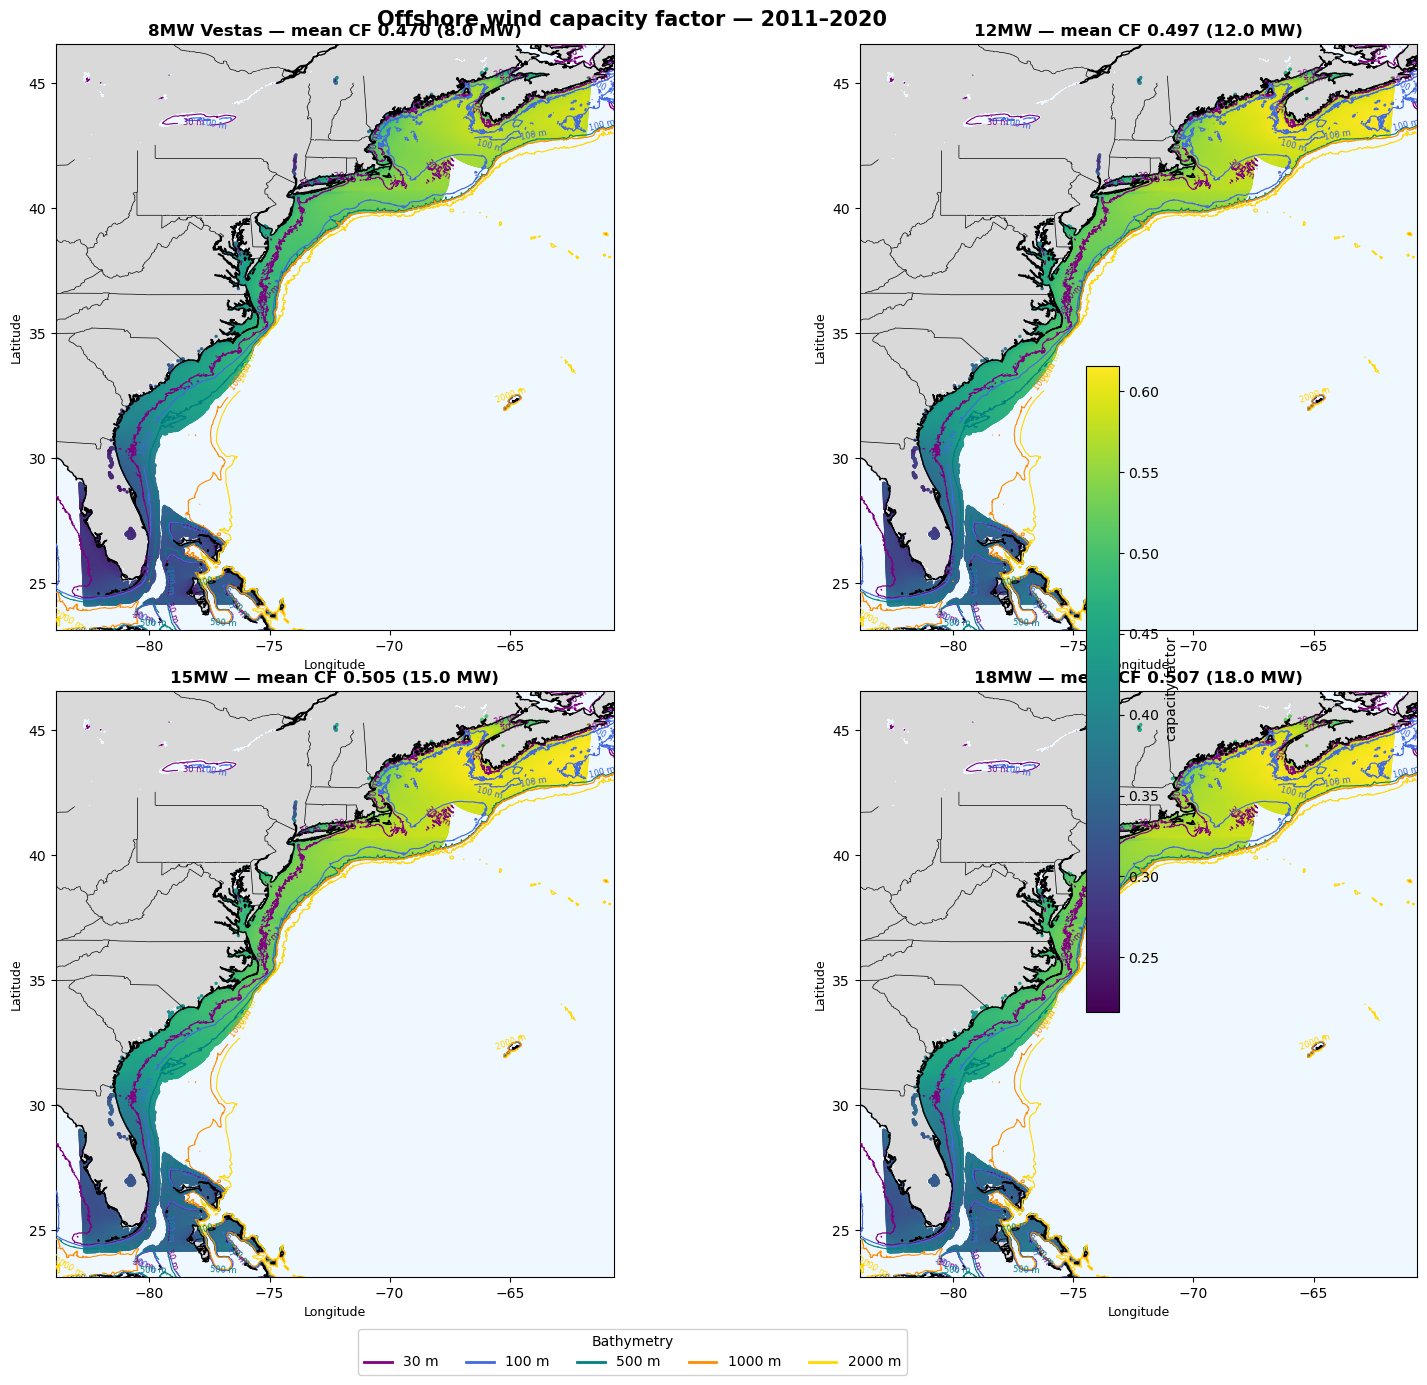

In [9]:
import numpy as np, zipfile, os
import geopandas as gpd, xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from numpy.lib import format as npformat

OUT_DIR = r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Wind"
DEPTH_NC    = r"C:\Users\rmiller9\Documents\East Coast Model\Depths_EastCoast_Offshore.nc"
COAST_SHP   = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_coastline.shp"
BORDERS_SHP = r"C:\Users\rmiller9\Documents\East Coast Model\Geospatial Data\CoastLine\ne_10m_admin_1_states_provinces_lines.shp"
TURBINES = ["ATB_8MW_2020_Vestas","ATB_12MW_2030","ATB_15MW_2030","ATB_18MW_2030"]
def short(n): return n.replace("ATB_","").replace("_2030","").replace("_2020_Vestas"," Vestas")

DEPTH_LEVELS = [30,100,500,1000,2000]
DEPTH_COLORS = {30:"purple",100:"royalblue",500:"teal",1000:"darkorange",2000:"gold"}

def _hdr(fp):
    v=npformat.read_magic(fp)
    try: return npformat._read_array_header(fp,v)
    except AttributeError:
        return npformat.read_array_header_1_0(fp) if v==(1,0) else npformat.read_array_header_2_0(fp)
def stream_mean(path,key,block=3000):
    with zipfile.ZipFile(path) as zf, zf.open(key+".npy") as f:
        shape,fort,dt=_hdr(f); T,S=shape; it=dt.itemsize; acc=np.zeros(S,np.float64)
        for r0 in range(0,T,block):
            r1=min(r0+block,T); acc+=np.frombuffer(f.read((r1-r0)*S*it),dt).reshape(r1-r0,S).astype(np.float32).sum(0)
    return (acc/T).astype(np.float32)

# geo overlays (once)
ds=xr.open_dataset(DEPTH_NC); lat_d=ds["lat"].values[::2]; lon_d=ds["lon"].values[::2]
depth=ds["depth"].values[::2,::2]; LonGrid,LatGrid=np.meshgrid(lon_d,lat_d); ds.close()
coast=gpd.read_file(COAST_SHP); borders=gpd.read_file(BORDERS_SHP)
coast=coast.set_crs(4326) if coast.crs is None else coast.to_crs(4326)
borders=borders.set_crs(4326) if borders.crs is None else borders.to_crs(4326)

# load CF per turbine
data={}
for name in TURBINES:
    p=os.path.join(OUT_DIR,f"GenPU_{name}_EastCoast_2011_2020.npz")
    if not os.path.exists(p): print("missing",name); continue
    G=np.load(p,allow_pickle=True); data[name]=dict(ll=G["LatLong"],cf=stream_mean(p,"Energy_pu"),rp=float(G["RatedPower"])); G.close()

vmax=max(np.percentile(d["cf"],99) for d in data.values())
vmin=min(d["cf"].min() for d in data.values())
all_lon=np.concatenate([d["ll"][:,1] for d in data.values()]); all_lat=np.concatenate([d["ll"][:,0] for d in data.values()])
XLIM=(all_lon.min()-1,all_lon.max()+1); YLIM=(all_lat.min()-1,all_lat.max()+1)

fig,axes=plt.subplots(2,2,figsize=(16,14))
for ax,(name,d) in zip(axes.flatten(),data.items()):
    ax.set_facecolor("#d9d9d9")
    ax.contourf(LonGrid,LatGrid,depth,levels=[0,depth.max()],colors=["aliceblue"],zorder=0)
    sc=ax.scatter(d["ll"][:,1],d["ll"][:,0],c=d["cf"],s=6,cmap="viridis",vmin=vmin,vmax=vmax,
                  edgecolors="none",zorder=2)
    for lvl in DEPTH_LEVELS:
        cs=ax.contour(LonGrid,LatGrid,depth,levels=[lvl],colors=[DEPTH_COLORS[lvl]],linewidths=0.8,zorder=3)
        ax.clabel(cs,inline=True,fontsize=6,fmt={lvl:f"{lvl} m"})
    coast.plot(ax=ax,linewidth=1.0,color="black",zorder=4)
    borders.plot(ax=ax,linewidth=0.5,color="black",zorder=4)
    ax.set_xlim(XLIM); ax.set_ylim(YLIM)
    ax.set_xlabel("Longitude",fontsize=9); ax.set_ylabel("Latitude",fontsize=9)
    ax.set_title(f"{short(name)} — mean CF {d['cf'].mean():.3f} ({d['rp']:.1f} MW)",fontsize=12,fontweight="bold")

cbar=fig.colorbar(sc,ax=axes,shrink=0.6,label="capacity factor")
depth_h=[Line2D([0],[0],color=DEPTH_COLORS[l],lw=2,label=f"{l} m") for l in DEPTH_LEVELS]
fig.legend(handles=depth_h,loc="lower center",ncol=len(DEPTH_LEVELS),frameon=True,
           framealpha=0.9,facecolor="white",title="Bathymetry",bbox_to_anchor=(0.5,0.0))
fig.suptitle("Offshore wind capacity factor — 2011–2020",fontsize=15,fontweight="bold")
plt.tight_layout(rect=[0,0.04,1,1])
plt.show()

Fixing an issue with 2020 data

In [ ]:
import numpy as np, os

OUT_DIR = r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Wind"
TURBINES = ["ATB_8MW_2020_Vestas","ATB_12MW_2030","ATB_15MW_2030","ATB_18MW_2030"]

for name in TURBINES:
    gpath = os.path.join(OUT_DIR, f"GenPU_{name}_EastCoast_2011_2020.npz")
    out   = os.path.join(OUT_DIR, f"GenPU_{name}_EastCoast_2011_2019.npz")
    if not os.path.exists(gpath): print(f"[missing] {os.path.basename(gpath)}"); continue
    if os.path.exists(out): print(f"[exists] {os.path.basename(out)}"); continue

    G = np.load(gpath, allow_pickle=True)
    tl = G["TimeList"]
    keep = np.array([t.year != 2020 for t in tl]); N = int(keep.sum())
    assert keep[:N].all() and not keep[N:].any(), "2020 not a contiguous tail"
    print(f"{name}: {len(tl):,} -> keep {N:,} (dropping {len(tl)-N} of 2020)")

    out_dict = {}
    for k in G.files:
        if k in ("Energy_pu","RawResource"): out_dict[k] = G[k][:N]
        elif k == "TimeList":                out_dict[k] = tl[:N]
        else:                                out_dict[k] = G[k]
    np.savez(out, **out_dict)
    G.close()
    print(f"  wrote {os.path.basename(out)}  {os.path.getsize(out)/1024**3:.2f} GB")
print("Strip done.")

In [ ]:
import numpy as np, zipfile, os
from numpy.lib import format as npformat
os.chdir(r"C:\Users\rmiller9\Documents\East Coast Model")
from WindTurbineTools_EastCoast import GetTurbineData

OUT_DIR  = r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Wind"
WIND_DIR = r"C:\Users\rmiller9\Documents\East Coast Model\Resource Data\Wind\EastCoast"
DESIGN_DIR = r"C:\Users\rmiller9\Documents\East Coast Model\Tech Designs\Wind"
RES_2020 = os.path.join(WIND_DIR, "EastCoast_2020_ws_only.npz")
TURBINES = ["ATB_8MW_2020_Vestas","ATB_12MW_2030","ATB_15MW_2030","ATB_18MW_2030"]
WS = {100:"windspeed_100m",140:"windspeed_140m",160:"windspeed_160m",200:"windspeed_200m"}
HA = np.array(sorted(WS))

def _hdr(fp):
    v=npformat.read_magic(fp)
    try: return npformat._read_array_header(fp,v)
    except AttributeError:
        return npformat.read_array_header_1_0(fp) if v==(1,0) else npformat.read_array_header_2_0(fp)
def stream_rows(path,key,r0,r1,block=512):
    with zipfile.ZipFile(path) as zf, zf.open(key+".npy") as f:
        shape,fort,dt=_hdr(f); T,S=shape; it=dt.itemsize
        f.read(r0*S*it); r=r0
        while r<r1:
            n=min(block,r1-r); yield r-r0, np.frombuffer(f.read(n*S*it),dt).reshape(n,S); r+=n
def stream_cols(path,key,cols,block=256):
    cols=np.asarray(cols)
    with zipfile.ZipFile(path) as zf, zf.open(key+".npy") as f:
        shape,fort,dt=_hdr(f); T,S=shape; it=dt.itemsize; out=np.empty((T,cols.size),dt)
        for r0 in range(0,T,block):
            r1=min(r0+block,T); blk=np.frombuffer(f.read((r1-r0)*S*it),dt).reshape(r1-r0,S); out[r0:r1]=blk[:,cols]
        return out
def copy_rows(mm,src,key,N):
    for off,blk in stream_rows(src,key,0,N): mm[off:off+blk.shape[0]]=blk
def bracket(hub):
    iu=int(np.argmin(np.abs(HA-hub)))
    if HA[iu]-hub<0: iu=min(iu+1,len(HA)-1)
    iu=max(iu,1); return iu-1,iu

LUT = {tuple(c):i for i,c in enumerate(np.load(RES_2020,allow_pickle=True)["coordinates"].astype(np.float32))}
new_tl = np.load(RES_2020, allow_pickle=True)["time_index"]

for name in TURBINES:
    f19 = os.path.join(OUT_DIR, f"GenPU_{name}_EastCoast_2011_2019.npz")
    out = os.path.join(OUT_DIR, f"GenPU_{name}_EastCoast_2011_2020.npz")
    if not os.path.exists(f19): print(f"[missing] {os.path.basename(f19)}"); continue

    G = np.load(f19, allow_pickle=True)
    LatLong = G["LatLong"].astype(np.float32); n_sites = LatLong.shape[0]; tl19 = G["TimeList"]
    try: cols = np.array([LUT[tuple(ll)] for ll in LatLong])
    except KeyError: print(f"  {name}: a site missing from 2020 resource — grids differ, skipping"); G.close(); continue

    HubHeight,_,_,PowerCurve,RatedPower = GetTurbineData(r"C:\Users\rmiller9\Documents\East Coast Model", os.path.join(DESIGN_DIR,name))
    il,iu = bracket(HubHeight); hL,hU = HA[il],HA[iu]
    h_ref,use_up = (hU,True) if hU<=HubHeight else (hL,False)
    L = stream_cols(RES_2020, WS[hL], cols).astype(np.float32)
    H = stream_cols(RES_2020, WS[hU], cols).astype(np.float32)
    L[L<0.01]=0.01; H[H<0.01]=0.01
    alpha = np.median(np.log(H/L)/np.log(hU/hL))
    WS_Hub = (H if use_up else L)*(HubHeight/h_ref)**alpha
    new_ep  = np.interp(WS_Hub.ravel(),PowerCurve[:,0],PowerCurve[:,1]).reshape(WS_Hub.shape).astype(np.float16)
    new_raw = WS_Hub.astype(np.float16)
    print(f"{name}: 2020 alpha={alpha:.3f} (want ~0.03); appending {new_ep.shape[0]} rows to {len(tl19):,}")

    N19 = len(tl19); newT = N19 + new_ep.shape[0]
    small = {k: G[k] for k in G.files if k not in ("Energy_pu","RawResource","TimeList")}
    ep = npformat.open_memmap(out+".ep.npy","w+",np.float16,(newT,n_sites)); copy_rows(ep,f19,"Energy_pu",N19); ep[N19:]=new_ep
    rw = npformat.open_memmap(out+".rw.npy","w+",np.float16,(newT,n_sites)); copy_rows(rw,f19,"RawResource",N19); rw[N19:]=new_raw
    np.savez(out, Energy_pu=ep, RawResource=rw, TimeList=np.concatenate([tl19,new_tl]), **small)
    del ep, rw; os.remove(out+".ep.npy"); os.remove(out+".rw.npy"); G.close()
    print(f"  wrote {os.path.basename(out)}  {newT:,} rows, {os.path.getsize(out)/1024**3:.2f} GB")
print("Append done.")

In [ ]:
G = np.load(os.path.join(OUTPUT_DIR,"GenPU_ATB_18MW_2030_EastCoast_2011_2020.npz"), allow_pickle=True)
tl = G["TimeList"]
yrs, cnts = np.unique([t.year for t in tl], return_counts=True)
print("years present:", dict(zip(yrs.tolist(), cnts.tolist())))
print("Energy_pu shape:", G["Energy_pu"].shape, "| sites:", G["LatLong"].shape[0])
print("2020 mean CF:", np.asarray(G["Energy_pu"],np.float32)[[i for i,t in enumerate(tl) if t.year==2020]].mean())
G.close()

In [ ]:
import numpy as np, zipfile, os
from numpy.lib import format as npformat

OUT_DIR = r"C:\Users\rmiller9\Documents\East Coast Model\Tech Outputs\Wind"
TURBINES = ["ATB_8MW_2020_Vestas","ATB_12MW_2030","ATB_15MW_2030","ATB_18MW_2030"]

def _hdr(fp):
    v=npformat.read_magic(fp)
    try: return npformat._read_array_header(fp,v)
    except AttributeError:
        return npformat.read_array_header_1_0(fp) if v==(1,0) else npformat.read_array_header_2_0(fp)
def shape_of(path,key):
    with zipfile.ZipFile(path) as zf, zf.open(key+".npy") as f: return _hdr(f)[0]
def mean_2020(path, tl):
    idx = np.array([i for i,t in enumerate(tl) if t.year==2020])
    lo, hi = int(idx.min()), int(idx.max())+1
    with zipfile.ZipFile(path) as zf, zf.open("Energy_pu.npy") as f:
        shape,fort,dt = _hdr(f); T,S = shape; it = int(dt.itemsize)
        f.read(int(lo)*int(S)*it)                      # python ints -> no 32-bit overflow
        blk = np.frombuffer(f.read(int(hi-lo)*int(S)*it), dt).reshape(hi-lo, S)
    return blk.astype(np.float32).mean()

for name in TURBINES:
    p=os.path.join(OUT_DIR,f"GenPU_{name}_EastCoast_2011_2020.npz")
    print("="*66)
    if not os.path.exists(p): print(f"{name}: MISSING"); continue
    G=np.load(p,allow_pickle=True); tl=G["TimeList"]
    yrs,cnts=np.unique([t.year for t in tl],return_counts=True)
    ep_shape=shape_of(p,"Energy_pu"); n_sites=G["LatLong"].shape[0]

    print(f"{name}")
    print(f"  years: {dict(zip(yrs.tolist(),cnts.tolist()))}")
    print(f"  Energy_pu {ep_shape} | RawResource {shape_of(p,'RawResource')} | TimeList {len(tl):,} | sites {n_sites:,}")
    ok_years = list(yrs)==list(range(2011,2021))
    ok_align = ep_shape[0]==len(tl) and ep_shape[1]==n_sites
    print(f"  2011-2020 complete: {ok_years} | time/site aligned: {ok_align} | 2020 steps: {cnts[yrs==2020][0] if 2020 in yrs else 0}")
    print(f"  2020 mean Energy_pu (CF): {mean_2020(p,tl):.3f}  (sane ~0.3-0.5; near 0 or absurd = bad splice)")
    G.close()
print("="*66,"\nDone.")